# Análisis de géneros en Steam Games 2025

## Pregunta principal

¿Qué géneros tienen más usuarios estimados y cuáles tienen mayor tiempo medio de juego?

En este notebook vamos a trabajar con los datos ya procesados por el script `src/analyze_genres.py`. La idea es visualizar los resultados y empezar a sacar conclusiones.

## 1. Importar librerías

Usamos `pandas` para trabajar con tablas y `matplotlib` para crear gráficos. Estas librerías ya están instaladas en el entorno virtual del proyecto.

In [34]:
# Path nos permite construir rutas de archivos de forma robusta.
from pathlib import Path

# pandas se usa para cargar y manipular tablas de datos.
import pandas as pd

# matplotlib se usa para crear graficos.
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Elegimos un estilo sencillo para que los graficos sean claros.
plt.style.use("default")

# Formateador para mostrar numeros con punto de miles: 100.000, 200.000, etc.
def formato_miles(valor, posicion):
    return f"{valor:,.0f}".replace(",", ".")

print("Librerias importadas correctamente")

Librerias importadas correctamente


## 2. Cargar los archivos procesados

Cargamos dos archivos:

- `resumen_generos.csv`: resumen completo por género.
- `resumen_generos_min_1000_juegos.csv`: resumen filtrado para quedarnos solo con géneros que tienen al menos 1000 juegos.

In [35]:
# Detectamos automaticamente la carpeta del proyecto.
# Esto evita errores si el notebook se ejecuta desde Steam_Games_2025 o desde la carpeta padre Proyectos.
cwd = Path.cwd()
candidates = [cwd, cwd.parent, cwd / "Steam_Games_2025"]

PROJECT_ROOT = next(
    path for path in candidates
    if (path / "data" / "processed" / "resumen_generos.csv").exists()
)

# Carpeta donde estan los CSV ya procesados.
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
print("Carpeta del proyecto:", PROJECT_ROOT)

# Cargamos el resumen completo y el resumen filtrado.
resumen_generos = pd.read_csv(DATA_PROCESSED / "resumen_generos.csv")
resumen_generos_filtrado = pd.read_csv(DATA_PROCESSED / "resumen_generos_min_1000_juegos.csv")

# Mostramos las primeras filas para comprobar que se ha cargado bien.
resumen_generos.head()

Carpeta del proyecto: c:\Users\djsmd\Desktop\DANI\Master Evolve\DATA_SCIENCE_ABRIL\Proyectos\Steam_Games_2025


,genero,cantidad_juegos,usuarios_estimados_total,usuarios_estimados_media,usuarios_estimados_mediana,tiempo_medio_horas_todos,juegos_con_tiempo_registrado,proporcion_positivas_media,total_resenas,tiempo_medio_horas_solo_con_tiempo,tiempo_mediano_horas_solo_con_tiempo,porcentaje_juegos_con_tiempo,usuarios_estimados_media_millones,usuarios_estimados_mediana_millones
0,Accion,36894,5805230000,157349,10000,1.87,3647,0.7476,92380325,18.92,3.73,9.89,0.157,0.01
1,Indie,63228,4302075000,68041,10000,0.96,5270,0.7611,53776067,11.49,3.23,8.33,0.068,0.01
2,Aventura,35495,3902770000,109953,10000,2.28,3381,0.7521,55631283,23.99,3.77,9.53,0.110,0.01
3,RPG,16350,2453290000,150048,10000,2.00,1869,0.7399,35449166,17.49,5.17,11.43,0.150,0.01
4,Gratis,8873,2075360000,233896,0,1.28,685,0.7532,28265214,16.59,1.32,7.72,0.234,0.00


### Qué significa esta tabla

Cada fila representa un género de Steam. Las columnas resumen información agregada de todos los juegos que pertenecen a ese género.

- `cantidad_juegos`: número de juegos incluidos en ese género.
- `usuarios_estimados_total`: suma acumulada de los usuarios estimados de todos los juegos del género. No representa usuarios únicos y por eso no será la métrica principal del análisis.
- `usuarios_estimados_media`: media de usuarios estimados por juego dentro del género.
- `usuarios_estimados_mediana`: valor central de usuarios estimados por juego dentro del género.
- `usuarios_estimados_media`: media de usuarios estimados por juego.
- `usuarios_estimados_mediana`: mediana de usuarios estimados por juego.
- `tiempo_medio_horas_todos`: media de tiempo en horas incluyendo también juegos con valor 0.
- `juegos_con_tiempo_registrado`: cantidad de juegos cuyo tiempo medio es mayor que 0.
- `tiempo_medio_horas_solo_con_tiempo`: media de tiempo en horas usando solo juegos con tiempo registrado.
- `tiempo_mediano_horas_solo_con_tiempo`: mediana de tiempo en horas usando solo juegos con tiempo registrado.
- `proporcion_positivas_media`: media de la proporción de valoraciones positivas.
- `total_resenas`: suma de valoraciones positivas y negativas de los juegos del género.

## 3. Revisión rápida de los datos

Antes de hacer gráficos, miramos cuántas filas y columnas tenemos y comprobamos las variables principales.

In [36]:
# shape devuelve el tamano de la tabla: (filas, columnas).
print("Resumen completo:", resumen_generos.shape)
print("Resumen filtrado:", resumen_generos_filtrado.shape)

# info muestra columnas, tipos de datos y valores no nulos.
resumen_generos.info()

Resumen completo: (33, 14)
Resumen filtrado: (12, 14)
<class 'pandas.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 14 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   genero                                33 non-null     str    
 1   cantidad_juegos                       33 non-null     int64  
 2   usuarios_estimados_total              33 non-null     int64  
 3   usuarios_estimados_media              33 non-null     int64  
 4   usuarios_estimados_mediana            33 non-null     int64  
 5   tiempo_medio_horas_todos              33 non-null     float64
 6   juegos_con_tiempo_registrado          33 non-null     int64  
 7   proporcion_positivas_media            33 non-null     float64
 8   total_resenas                         33 non-null     int64  
 9   tiempo_medio_horas_solo_con_tiempo    28 non-null     float64
 10  tiempo_mediano_horas_solo_con_tiempo  28 non-

### Cómo interpretar la salida anterior

`Resumen completo: (33, 7)` significa que la tabla completa tiene 33 filas y 7 columnas. En este caso, las 33 filas corresponden a 33 géneros distintos.

`Resumen filtrado: (12, 7)` significa que, después de quedarnos solo con géneros que tienen al menos 1000 juegos, quedan 12 géneros y las mismas 7 columnas.

`Non-Null Count` indica cuántos valores no vacíos hay en cada columna. Si aparece `33 non-null`, significa que esa columna tiene datos en las 33 filas.

`Dtype` indica el tipo de dato:

- `str`: texto.
- `int64`: número entero.
- `float64`: número decimal.

Esta revision sirve para comprobar que la tabla está limpia y lista para analizar: tiene pocas columnas, no aparecen nulos y los tipos de datos son coherentes.

## 4. Géneros con mas usuarios estimados por juego

Para esta parte no usamos `usuarios_estimados_total` como métrica principal, porque suma usuarios por juego y puede generar cifras enormes y poco intuitivas. En su lugar usamos `usuarios_estimados_media`, que representa la media de usuarios estimados por juego dentro de cada género.

También usamos el resumen filtrado con géneros de al menos 1000 juegos para evitar que géneros muy pequeños distorsionen el ranking.

In [37]:
# Ordenamos de mayor a menor por usuarios estimados medios por juego.
top_usuarios = resumen_generos_filtrado.sort_values("usuarios_estimados_media", ascending=False).head(10)

# Mostramos solo las columnas necesarias para responder esta parte de la pregunta.
top_usuarios[["genero", "cantidad_juegos", "usuarios_estimados_media", "usuarios_estimados_mediana", "usuarios_estimados_total"]]

,genero,cantidad_juegos,usuarios_estimados_media,usuarios_estimados_mediana,usuarios_estimados_total
8,Multijugador masivo,2129,486198,10000,1035115000
4,Gratis,8873,233896,0,2075360000
0,Accion,36894,157349,10000,5805230000
3,RPG,16350,150048,10000,2453290000
5,Estrategia,17380,114714,10000,1993730000
2,Aventura,35495,109953,10000,3902770000
6,Simulacion,18596,96333,10000,1791400000
10,Deportes,3948,85071,10000,335860000
1,Indie,63228,68041,10000,4302075000
11,Carreras,3302,66800,10000,220575000


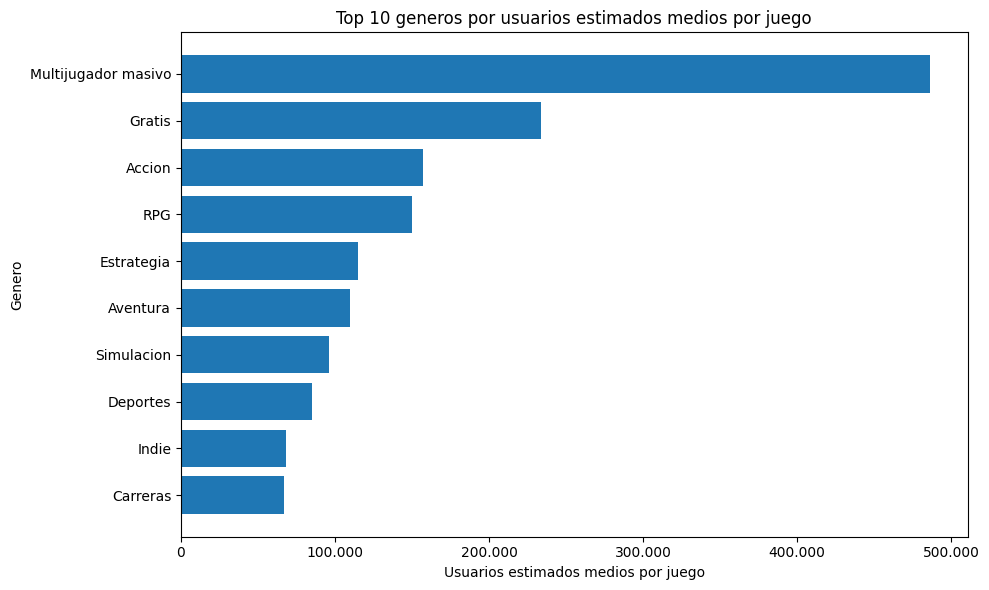

In [38]:
# Creamos un grafico de barras horizontal para que los nombres de generos se lean mejor.
fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(top_usuarios["genero"][::-1], top_usuarios["usuarios_estimados_media"][::-1])
ax.set_title("Top 10 generos por usuarios estimados medios por juego")
ax.set_xlabel("Usuarios estimados medios por juego")
ax.set_ylabel("Genero")
ax.xaxis.set_major_formatter(FuncFormatter(formato_miles))

plt.tight_layout()
plt.show()

### Interpretación inicial

Este ranking responde mejor a la pregunta de que géneros tienen juegos con mas usuarios de media. Al usar usuarios medios por juego, evitamos que los géneros con muchísimos juegos ganen solo por acumulacion.

Aun así, `usuarios_estimados_total` se mantiene en la tabla como dato de contexto, pero no debe interpretarse como personas únicas. Es una suma acumulada por juegos. Si una misma persona juega a varios juegos de Acción, puede estar representada varias veces en esa suma.

En el gráfico usamos el número completo, no millones abreviados. Por ejemplo, `486.198` significa aproximadamente 486.198 usuarios estimados de media por juego.

## 5. Géneros con mayor tiempo medio de juego

Para esta parte usamos el archivo filtrado con géneros de al menos 1000 juegos. Así evitamos que un género pequeño salga arriba solo por unos pocos casos extremos.

También usamos `tiempo_medio_horas_solo_con_tiempo`, porque el dataset tiene muchísimos juegos con tiempo medio igual a 0. Si incluyeramos esos ceros, la media quedaria artificialmente baja.

In [39]:
# Usamos el resumen filtrado para evitar que generos con muy pocos juegos distorsionen la media.
top_tiempo = resumen_generos_filtrado.sort_values("tiempo_medio_horas_solo_con_tiempo", ascending=False).head(10)

top_tiempo[["genero", "cantidad_juegos", "juegos_con_tiempo_registrado", "tiempo_medio_horas_solo_con_tiempo", "tiempo_mediano_horas_solo_con_tiempo"]]

,genero,cantidad_juegos,juegos_con_tiempo_registrado,tiempo_medio_horas_solo_con_tiempo,tiempo_mediano_horas_solo_con_tiempo
6,Simulacion,18596,1929,37.47,4.22
8,Multijugador masivo,2129,303,32.42,4.43
7,Casual,38719,2498,28.32,2.80
2,Aventura,35495,3381,23.99,3.77
0,Accion,36894,3647,18.92,3.73
3,RPG,16350,1869,17.49,5.17
9,Acceso anticipado,9121,527,17.08,4.08
4,Gratis,8873,685,16.59,1.32
5,Estrategia,17380,1791,15.77,4.68
10,Deportes,3948,355,12.18,2.53


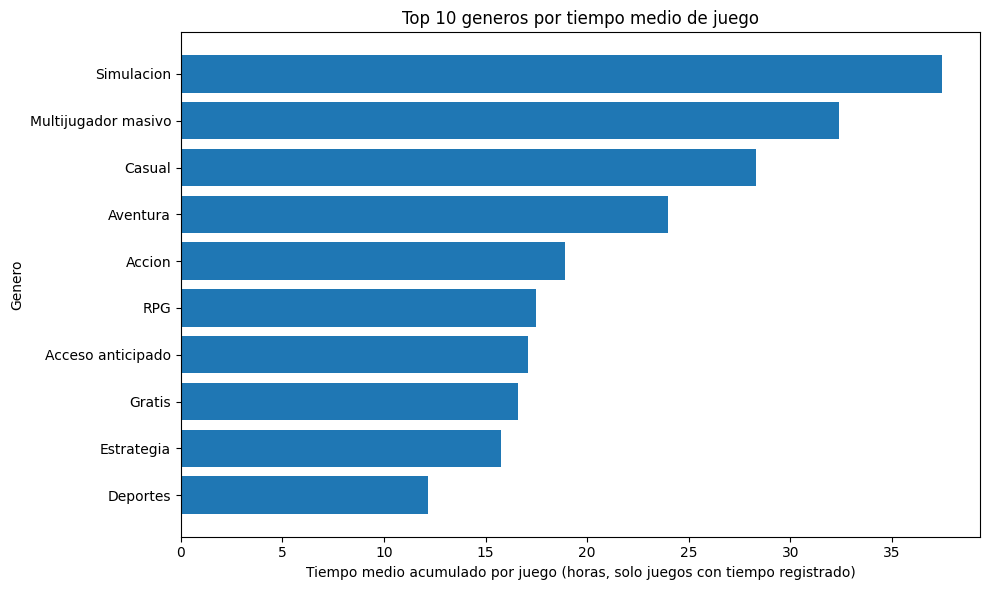

In [40]:
# Graficamos el tiempo medio de juego por genero.
fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(top_tiempo["genero"][::-1], top_tiempo["tiempo_medio_horas_solo_con_tiempo"][::-1])
ax.set_title("Top 10 generos por tiempo medio de juego")
ax.set_xlabel("Tiempo medio acumulado por juego (horas, solo juegos con tiempo registrado)")
ax.set_ylabel("Genero")

plt.tight_layout()
plt.show()

### Interpretación inicial

Los géneros con mas usuarios no son necesariamente los que tienen mayor tiempo medio de juego. Simulación y Multijugador masivo destacan por tiempo medio acumulado cuando miramos solo juegos con tiempo registrado.

El filtro de al menos 1000 juegos ayuda a que la comparacion sea mas estable. Sin ese filtro, géneros con pocos juegos pueden aparecer muy arriba por casos extremos.

Aun así, esta media debe interpretarse con cuidado: algunos juegos tienen valores de tiempo muy altos y pueden subir la media. Por eso también mostramos la mediana.

## 6. Comparación entre usuarios medios y tiempo medio

Este gráfico ayuda a ver si los géneros cuyos juegos tienen mas usuarios de media también son los que mas tiempo medio generan.

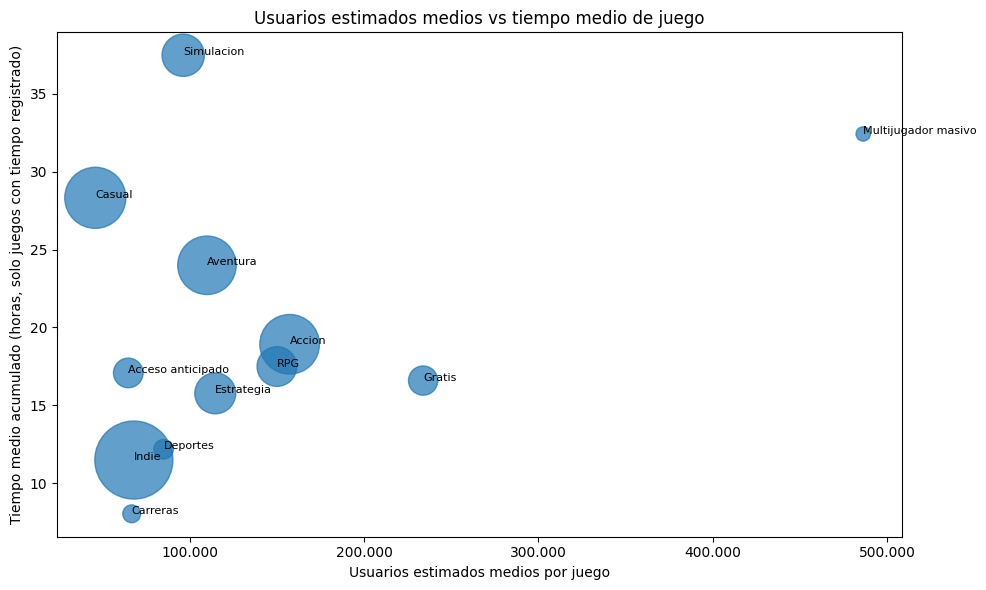

In [41]:
# Cada punto representa un genero.
# Eje X: usuarios estimados medios por juego.
# Eje Y: tiempo medio en horas, solo para juegos con tiempo registrado.
# Tamano del punto: cantidad de juegos del genero.
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    resumen_generos_filtrado["usuarios_estimados_media"],
    resumen_generos_filtrado["tiempo_medio_horas_solo_con_tiempo"],
    s=resumen_generos_filtrado["cantidad_juegos"] / 20,
    alpha=0.7,
)

# Anadimos el nombre de cada genero al lado de su punto.
for _, row in resumen_generos_filtrado.iterrows():
    ax.annotate(row["genero"], (row["usuarios_estimados_media"], row["tiempo_medio_horas_solo_con_tiempo"]), fontsize=8)

ax.set_title("Usuarios estimados medios vs tiempo medio de juego")
ax.set_xlabel("Usuarios estimados medios por juego")
ax.set_ylabel("Tiempo medio acumulado (horas, solo juegos con tiempo registrado)")
ax.xaxis.set_major_formatter(FuncFormatter(formato_miles))

plt.tight_layout()
plt.show()

### Interpretación inicial

Este gráfico permite comparar popularidad media por juego y tiempo medio. Así evitamos mezclar la popularidad del género con el simple hecho de que algunos géneros tienen muchísimos mas juegos que otros.

La lectura principal es que popularidad media y tiempo medio no miden lo mismo. Un género puede tener juegos con muchos usuarios de media, pero no necesariamente ser el género donde se juega durante mas tiempo.

## 7. Conclusiones provisionales

- Multijugador masivo, Gratis y Acción destacan por usuarios estimados medios por juego entre los géneros con al menos 1000 juegos.
- `usuarios_estimados_total` no se usa como métrica principal porque es una suma acumulada y puede dar cifras muy infladas.
- Simulación y Multijugador masivo destacan por tiempo medio de juego cuando analizamos solo juegos con tiempo registrado.
- Los géneros con mas usuarios no son siempre los géneros con mayor tiempo medio.
- Es importante filtrar géneros con pocos juegos para evitar conclusiones poco representativas.

Estas conclusiones son provisionales. En una siguiente fase se podría analizar la relación con precio, valoraciones o ano de lanzamiento.